# Data Science in Chemical Engineering

## Exploratory Data Analysis and Basline model (i) linear reggressor (Elastic Net)

The current section implements **Task 1: Exploratory Data Analysis**.

In [2]:
# Uncomment the code to install required packages if you haven't already.
""" import sys
print('Installing required packages...')
!{sys.executable} -m pip install --upgrade pandas numpy matplotlib seaborn scikit-learn -q
print('Installation complet e""') """

' import sys\nprint(\'Installing required packages...\')\n!{sys.executable} -m pip install --upgrade pandas numpy matplotlib seaborn scikit-learn -q\nprint(\'Installation complet e""\') '

# Task 1 - Exploratory Data Analysis

The goal of Task 1 is to understand the structure of the process dataset before fitting any models. The analysis focuses on dataset shape, schema, missing values, input-space coverage, output distributions, deterministic outputs, input-output couplings, and degenerate process regions.

`test.csv` is inspected only to compare domain coverage. It is not used for model tuning.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

input_cols = list(train.columns[:9])
output_cols = list(train.columns[9:])

key_outputs = [
    "Q1_MW", "Q2_MW", "T_reactor_out", "X_CO", "n3_total",
    "n4_total", "x_MeOH_4", "x_H2O_4", "MeOH_recovery",
    "MeOH_purity_stream4",
]

## 1.1 Load Data And Define Schema

The first nine columns are process inputs. The remaining nineteen columns are simulator outputs.

In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

schema_summary = pd.DataFrame({
    "column": train.columns,
    "role": ["input"] * len(input_cols) + ["output"] * len(output_cols),
    "dtype": train.dtypes.astype(str).values,
    "train_missing": train.isna().sum().values,
    "test_missing": test.isna().sum().values,
})
schema_summary

Train shape: (8000, 28)
Test shape:  (2000, 28)


,column,role,dtype,train_missing,test_missing
0,n1_total,input,float64,0,0
1,y_CO_1,input,float64,0,0
2,y_H2O_1,input,float64,0,0
3,n2_total,input,float64,0,0
4,T1,input,float64,0,0
5,T_reactor_in,input,float64,0,0
6,P_R,input,float64,0,0
7,T_flash,input,float64,0,0
8,T4,input,float64,0,0
9,Q1_MW,output,float64,0,0


In [5]:
print("Input columns:")
print(input_cols)

print("\nOutput columns:")
print(output_cols)

print("\nTotal missing values in train:", int(train.isna().sum().sum()))
print("Total missing values in test: ", int(test.isna().sum().sum()))

Input columns:
['n1_total', 'y_CO_1', 'y_H2O_1', 'n2_total', 'T1', 'T_reactor_in', 'P_R', 'T_flash', 'T4']

Output columns:
['Q1_MW', 'Q2_MW', 'T_reactor_out', 'X_CO', 'T3', 'P3', 'n3_total', 'y_CO_3', 'y_H2_3', 'y_MeOH_3', 'y_H2O_3', 'P4', 'n4_total', 'x_CO_4', 'x_H2_4', 'x_MeOH_4', 'x_H2O_4', 'MeOH_recovery', 'MeOH_purity_stream4']

Total missing values in train: 0
Total missing values in test:  0


**Observation.** The files have the expected structure: 8,000 training rows and 2,000 held-out test rows, with 28 numeric columns. No missing values are present, so no imputation is required.

## 1.2 Helper Functions

In [6]:
def summary_table(df, cols):
    return df[cols].agg(["min", "mean", "std", "max"]).T


def plot_hist_grid(df, cols, title, bins=35, cols_per_row=3):
    n_rows = int(np.ceil(len(cols) / cols_per_row))
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(5 * cols_per_row, 3.5 * n_rows))
    axes = np.asarray(axes).ravel()

    for ax, col in zip(axes, cols):
        sns.histplot(df[col], bins=bins, kde=False, ax=ax, color="#2f6f8f")
        ax.set_title(col)
        ax.set_xlabel("")

    for ax in axes[len(cols):]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=16)
    fig.tight_layout()
    plt.show()


def top_input_correlations(df, inputs, outputs, n=5):
    
    #Find the strongest linear correlations between inputs and selected outputs.
    
    rows = []
    for output in outputs:
        corr = df[inputs + [output]].corr(numeric_only=True)[output].drop(output)
        ordered = corr.reindex(corr.abs().sort_values(ascending=False).index).head(n)
        for input_col, value in ordered.items():
            rows.append({"output": output, "input": input_col, "correlation": value})
    return pd.DataFrame(rows)


def top_rank_correlations(df, inputs, outputs, n=5):
    # Compare linear and rank-based monotonic input-output associations.
    rows = []
    for output in outputs:
        pearson = df[inputs + [output]].corr(method="pearson", numeric_only=True)[output].drop(output)
        spearman = df[inputs + [output]].corr(method="spearman", numeric_only=True)[output].drop(output)
        ordered_inputs = spearman.abs().sort_values(ascending=False).head(n).index

        for input_col in ordered_inputs:
            rows.append({
                "output": output,
                "input": input_col,
                "pearson": pearson.loc[input_col],
                "spearman": spearman.loc[input_col],
                "abs_spearman": abs(spearman.loc[input_col]),
            })
    return pd.DataFrame(rows)


def scatter_with_optional_hue(df, x, y, hue=None, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    if hue is None:
        sns.scatterplot(data=df, x=x, y=y, s=18, alpha=0.45, linewidth=0, ax=ax)
    else:
        sns.scatterplot(data=df, x=x, y=y, hue=hue, palette="viridis", s=18, alpha=0.55, linewidth=0, ax=ax)
        ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(title or f"{x} vs {y}")
    fig.tight_layout()
    plt.show()


def highlight_degenerate_scatter(df, x, y, degenerate_mask, title):

    #Plot two variables while highlighting degenerate no-liquid rows.
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df.loc[~degenerate_mask], x=x, y=y, s=18, alpha=0.25, linewidth=0, color="#4c78a8", label="liquid exists", ax=ax)
    sns.scatterplot(data=df.loc[degenerate_mask], x=x, y=y, s=70, marker="X", color="#d62728", label="no liquid", ax=ax)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 1.3 Input Space Coverage

The training set is used for EDA and model development. The test set is compared only to confirm that it covers the same operating domain. Here we visualize the **marginal distributions** of the input variables using histograms.

In [7]:
summary_table(train, input_cols).round(6)

,min,mean,std,max
n1_total,800.021879,1199.115741,231.116240,1599.985670
y_CO_1,0.250004,0.349961,0.057828,0.449956
y_H2O_1,0.000001,0.020034,0.011578,0.039996
n2_total,0.014307,199.994560,115.344204,399.991182
T1,290.002363,304.997717,8.663555,319.996512
T_reactor_in,470.005367,504.894480,20.227755,539.997755
P_R,50.002557,64.970151,8.667822,79.998742
T_flash,290.005441,325.042349,20.196321,359.992145
T4,280.001585,304.397619,14.890788,339.995511


In [8]:
summary_table(test, input_cols).round(6)

,min,mean,std,max
n1_total,801.301058,1191.049957,232.647604,1599.574390
y_CO_1,0.250348,0.350267,0.057083,0.449981
y_H2O_1,0.000014,0.019964,0.011518,0.039977
n2_total,1.073504,199.391111,114.365736,399.732749
T1,290.008717,304.960415,8.681343,319.984883
T_reactor_in,470.029545,504.958621,20.571651,539.947774
P_R,50.009077,64.887511,8.848537,79.986806
T_flash,290.052590,325.036250,20.282754,359.950650
T4,280.034203,304.300760,14.640633,339.785098


In [9]:
range_comparison = pd.DataFrame({
    "train_min": train[input_cols].min(),
    "train_max": train[input_cols].max(),
    "test_min": test[input_cols].min(),
    "test_max": test[input_cols].max(),
})
range_comparison.round(6)

,train_min,train_max,test_min,test_max
n1_total,800.021879,1599.985670,801.301058,1599.574390
y_CO_1,0.250004,0.449956,0.250348,0.449981
y_H2O_1,0.000001,0.039996,0.000014,0.039977
n2_total,0.014307,399.991182,1.073504,399.732749
T1,290.002363,319.996512,290.008717,319.984883
T_reactor_in,470.005367,539.997755,470.029545,539.947774
P_R,50.002557,79.998742,50.009077,79.986806
T_flash,290.005441,359.992145,290.052590,359.950650
T4,280.001585,339.995511,280.034203,339.785098


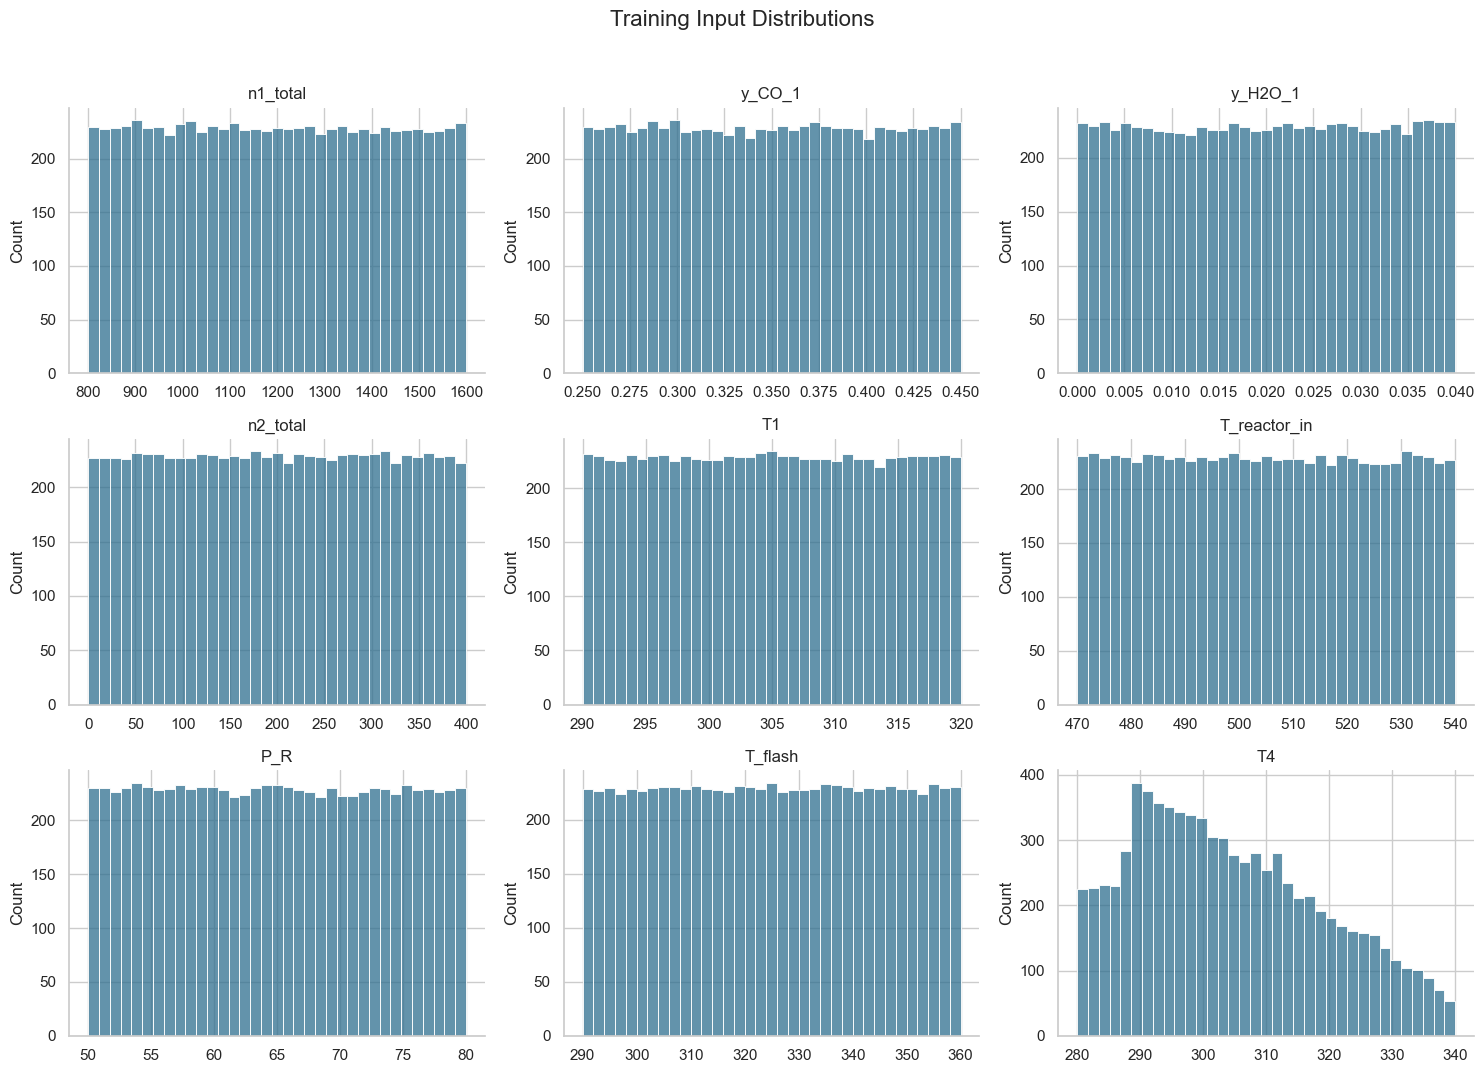

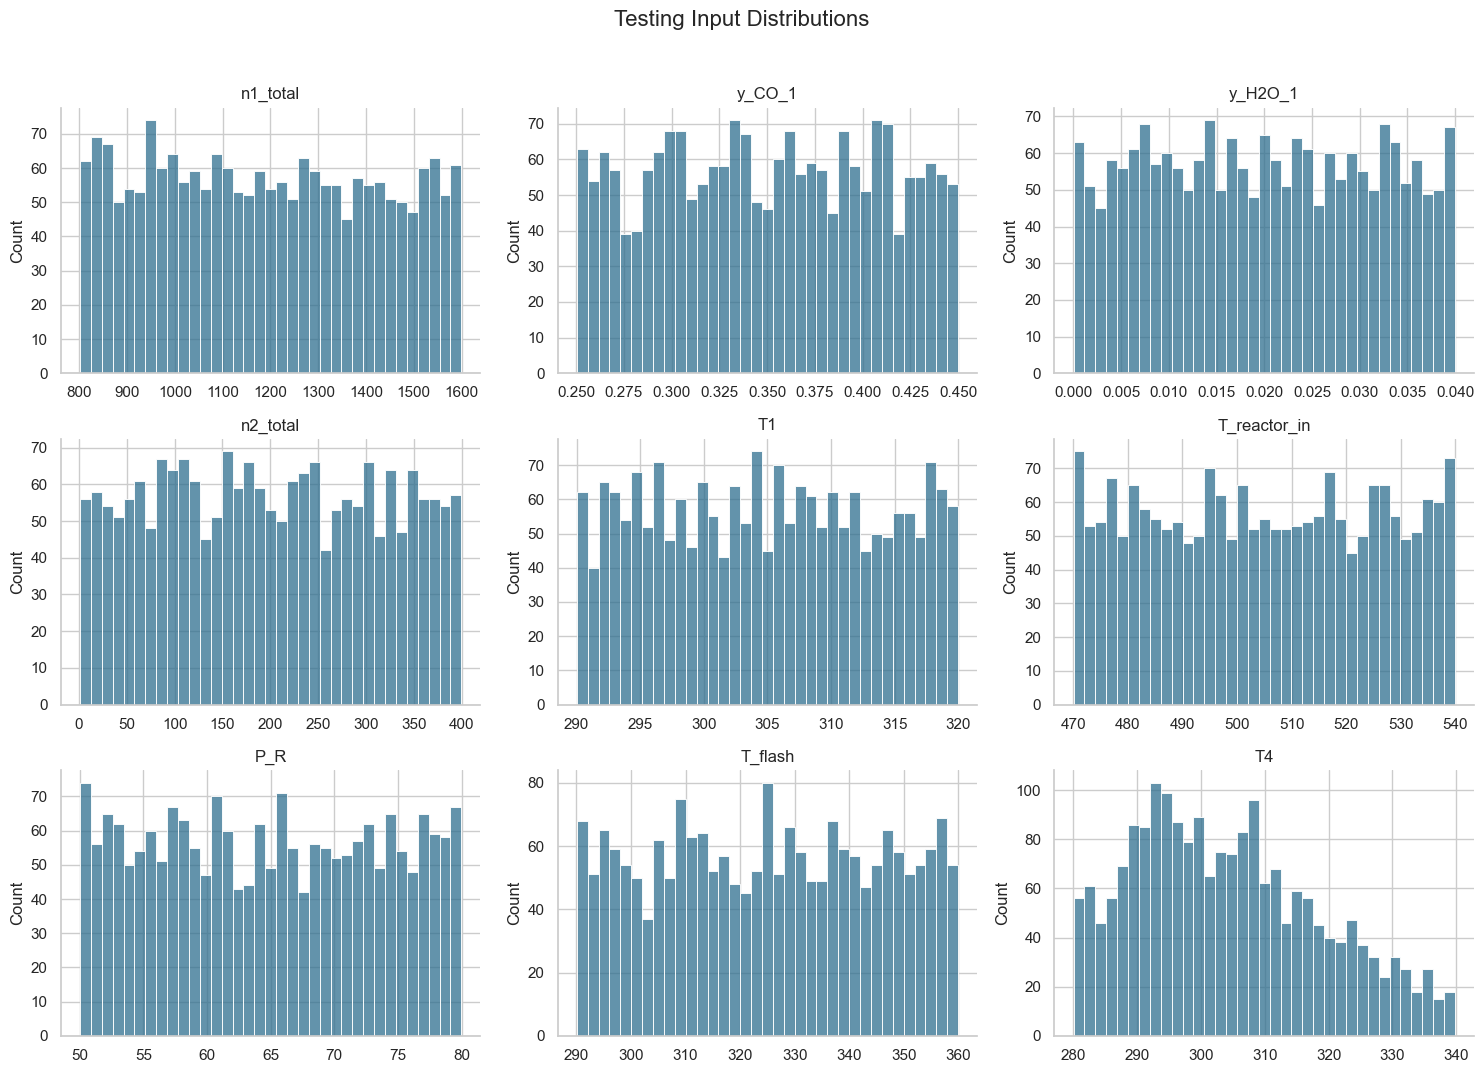

In [10]:
plot_hist_grid(train, input_cols, "Training Input Distributions")
plot_hist_grid(test, input_cols, "Testing Input Distributions")

**Observation.** The input variables are spread across their allowed domains and the train/test ranges are very similar. This supports treating final test evaluation as interpolation rather than extrapolation.



## 1.4 Output Distributions

Outputs have different units and scales: heat duties, temperatures, conversions, flowrates, mole fractions, recovery, and purity. Here we visualize the **marginal distributions** of these outputs using histograms.

In [11]:
summary_table(train, output_cols).round(6)

,min,mean,std,max
Q1_MW,1.094168,2.298201,0.496172,3.928320
Q2_MW,-0.083087,-0.012953,0.013186,0.000000
T_reactor_out,595.279826,616.561134,8.286243,637.963270
X_CO,0.053995,0.115490,0.027205,0.221069
T3,290.005441,325.042349,20.196321,359.992145
P3,50.002557,64.970151,8.667822,79.998742
n3_total,706.532106,1245.522853,231.664201,1835.808770
y_CO_3,0.156152,0.300158,0.063844,0.469836
y_H2_3,0.519254,0.690839,0.063845,0.835732
y_MeOH_3,0.000743,0.007836,0.006241,0.037280


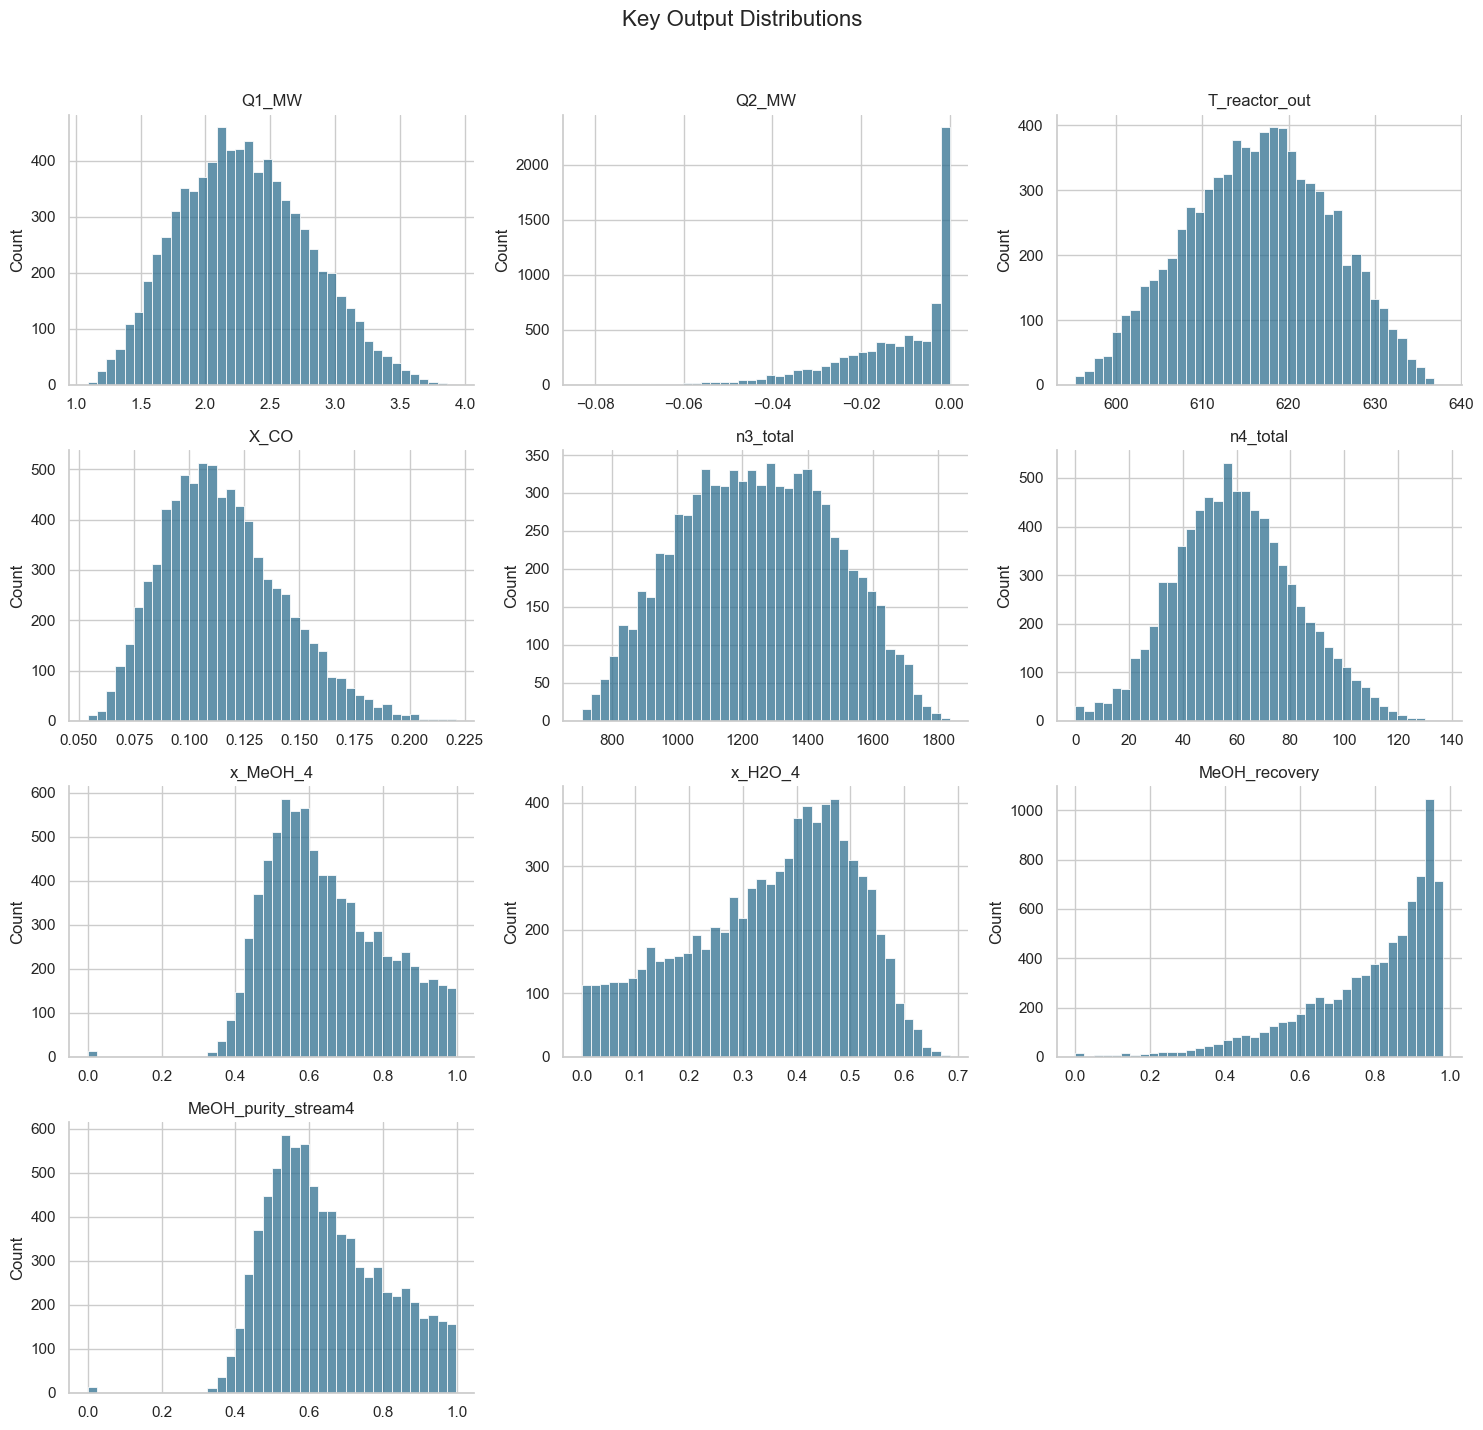

In [12]:
plot_hist_grid(train, key_outputs, "Key Output Distributions", bins=40, cols_per_row=3)

In [13]:
output_variability = pd.DataFrame({
    "mean": train[output_cols].mean(),
    "std": train[output_cols].std(),
    "min": train[output_cols].min(),
    "max": train[output_cols].max(),
    "unique_values": train[output_cols].nunique(),
    "zero_count": (train[output_cols] == 0).sum(),
})
output_variability.round(6)

,mean,std,min,max,unique_values,zero_count
Q1_MW,2.298201,0.496172,1.094168,3.928320,8000,0
Q2_MW,-0.012953,0.013186,-0.083087,0.000000,7988,13
T_reactor_out,616.561134,8.286243,595.279826,637.963270,8000,0
X_CO,0.115490,0.027205,0.053995,0.221069,7999,0
T3,325.042349,20.196321,290.005441,359.992145,8000,0
P3,64.970151,8.667822,50.002557,79.998742,8000,0
n3_total,1245.522853,231.664201,706.532106,1835.808770,8000,0
y_CO_3,0.300158,0.063844,0.156152,0.469836,8000,0
y_H2_3,0.690839,0.063845,0.519254,0.835732,7999,0
y_MeOH_3,0.007836,0.006241,0.000743,0.037280,8000,0


**Observation.** Several outputs are bounded mole fractions, while temperatures and flowrates have much larger numeric scales. Some liquid-stream outputs contain exact zeros due to no-liquid flash cases.

## 1.5 Deterministic And Redundant Outputs

Some outputs are direct copies of inputs or are constrained by mole-fraction balances.

In [14]:
liquid_exists = train["n4_total"] > 0

deterministic_checks = pd.Series({
    "T3 equals T_flash": np.allclose(train["T3"], train["T_flash"]),
    "P3 equals P_R": np.allclose(train["P3"], train["P_R"]),
    "P4 equals P_R": np.allclose(train["P4"], train["P_R"]),
    "MeOH_purity_stream4 equals x_MeOH_4": np.allclose(train["MeOH_purity_stream4"], train["x_MeOH_4"]),
    "vapor mole fractions sum to 1": np.allclose(train[["y_CO_3", "y_H2_3", "y_MeOH_3", "y_H2O_3"]].sum(axis=1), 1.0),
    "liquid mole fractions sum to 1 when liquid exists": np.allclose(train.loc[liquid_exists, ["x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4"]].sum(axis=1), 1.0),
    "liquid mole fractions are zero when no liquid exists": bool((train.loc[~liquid_exists, ["x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4"]].sum(axis=1) == 0).all()),
})
deterministic_checks

T3 equals T_flash                                       True
P3 equals P_R                                           True
P4 equals P_R                                           True
MeOH_purity_stream4 equals x_MeOH_4                     True
vapor mole fractions sum to 1                           True
liquid mole fractions sum to 1 when liquid exists       True
liquid mole fractions are zero when no liquid exists    True
dtype: bool

**Observation.** `T3`, `P3`, `P4`, and `MeOH_purity_stream4` are deterministic or duplicate outputs. Vapor and liquid compositions also contain one redundant degree of freedom because mole fractions sum to one.

## 1.6 Correlation And Coupling Analysis

Pearson correlations identify dominant linear input-output relationships. Because process behavior can also be monotonic but nonlinear, rank-based Spearman correlations are compared against Pearson values for the main outputs. Scatter plots with a third variable encoded by color are then used to visually inspect joint distributions, interaction effects, and regime changes that correlation coefficients alone may miss.

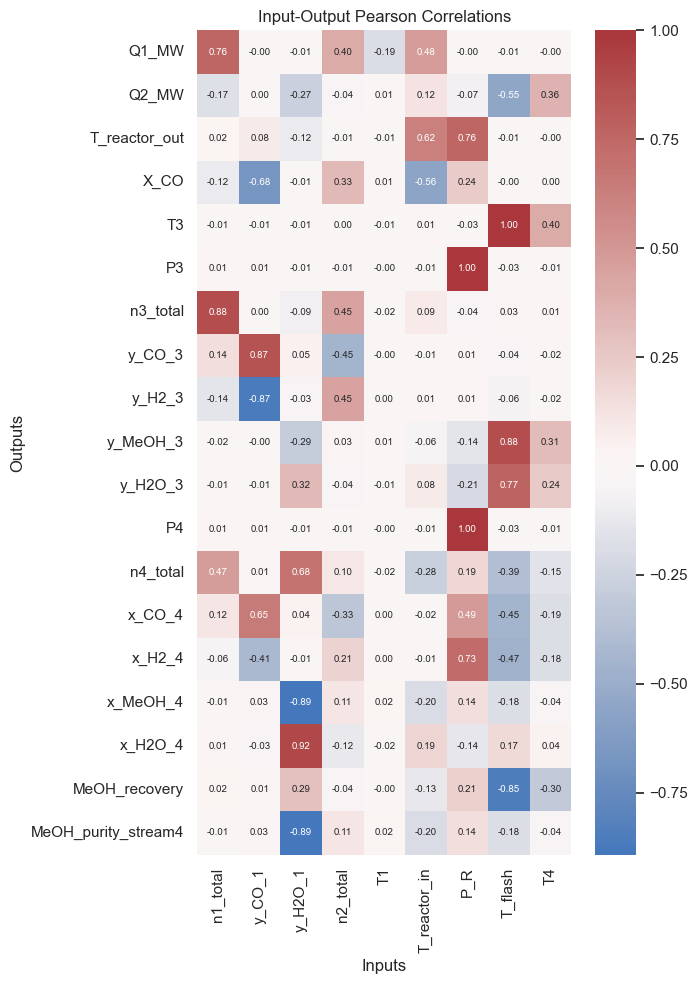

In [15]:
input_output_corr = train[input_cols + output_cols].corr(numeric_only=True).loc[output_cols, input_cols]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(
    input_output_corr,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Input-Output Pearson Correlations")
ax.set_xlabel("Inputs")
ax.set_ylabel("Outputs")
fig.tight_layout()
plt.show()

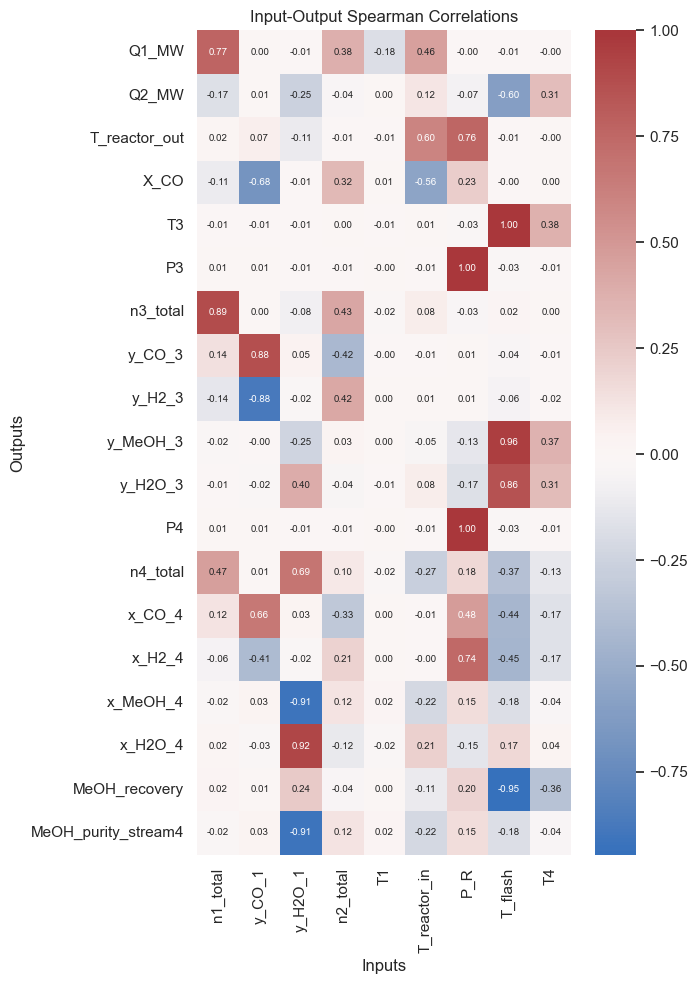

In [16]:
import os

input_output_spearman = train[input_cols + output_cols].corr(method="spearman", numeric_only=True).loc[output_cols, input_cols]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(
    input_output_spearman,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title("Input-Output Spearman Correlations")
ax.set_xlabel("Inputs")
ax.set_ylabel("Outputs")
fig.tight_layout()
#os.makedirs("report/images", exist_ok=True)
#fig.savefig("report/images/spearman_corr.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved spearman_corr.png")

In [17]:
top_corr_outputs = ["Q1_MW", "Q2_MW", "T_reactor_out", "X_CO", "n4_total", "x_MeOH_4", "MeOH_recovery"]
top_input_correlations(train, input_cols, top_corr_outputs, n=5).round(3)

,output,input,correlation
0,Q1_MW,n1_total,0.760
1,Q1_MW,T_reactor_in,0.479
2,Q1_MW,n2_total,0.398
3,Q1_MW,T1,-0.191
4,Q1_MW,y_H2O_1,-0.009
5,Q2_MW,T_flash,-0.551
6,Q2_MW,T4,0.363
7,Q2_MW,y_H2O_1,-0.270
8,Q2_MW,n1_total,-0.174
9,Q2_MW,T_reactor_in,0.121


In [18]:
top_rank_correlations(train, input_cols, top_corr_outputs, n=5).round(3)

,output,input,pearson,spearman,abs_spearman
0,Q1_MW,n1_total,0.760,0.767,0.767
1,Q1_MW,T_reactor_in,0.479,0.461,0.461
2,Q1_MW,n2_total,0.398,0.383,0.383
3,Q1_MW,T1,-0.191,-0.183,0.183
4,Q1_MW,y_H2O_1,-0.009,-0.008,0.008
5,Q2_MW,T_flash,-0.551,-0.601,0.601
6,Q2_MW,T4,0.363,0.308,0.308
7,Q2_MW,y_H2O_1,-0.270,-0.254,0.254
8,Q2_MW,n1_total,-0.174,-0.173,0.173
9,Q2_MW,T_reactor_in,0.121,0.117,0.117


**Observation.** Pearson correlation measures linear association, while Spearman correlation measures monotonic association after ranking the data. Similar Pearson and Spearman values indicate mostly linear monotonic trends; noticeably different values suggest monotonic but nonlinear behavior. These metrics still do not fully capture multi-input interactions or discrete regime changes, so the scatterplots and no-liquid analysis remain necessary.

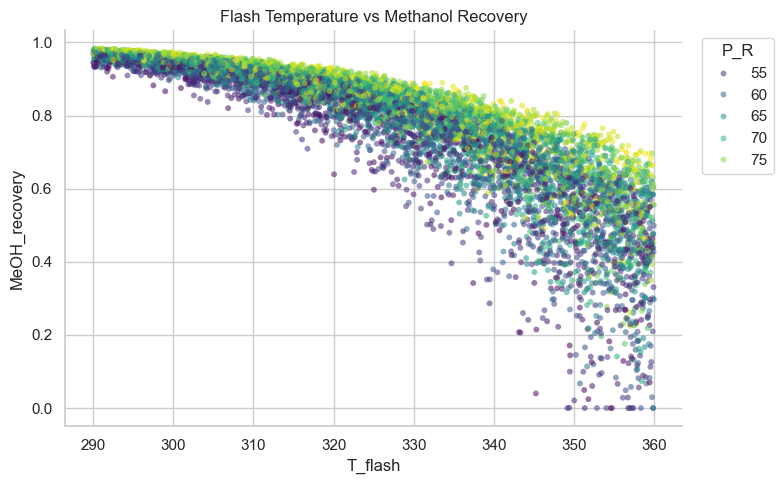

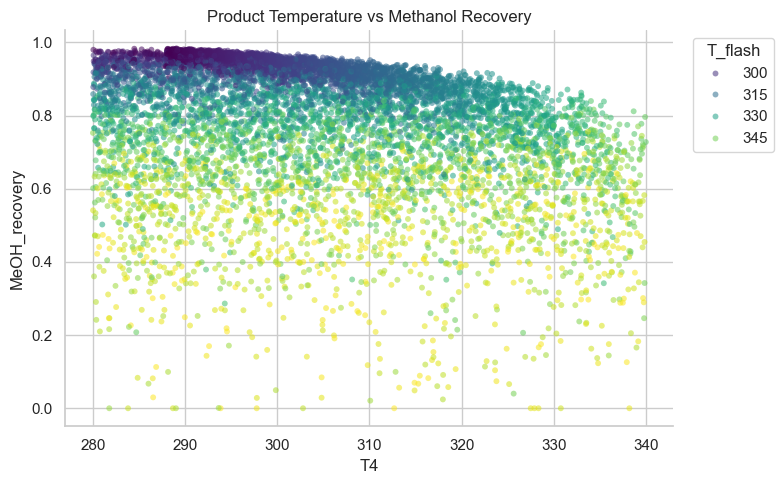

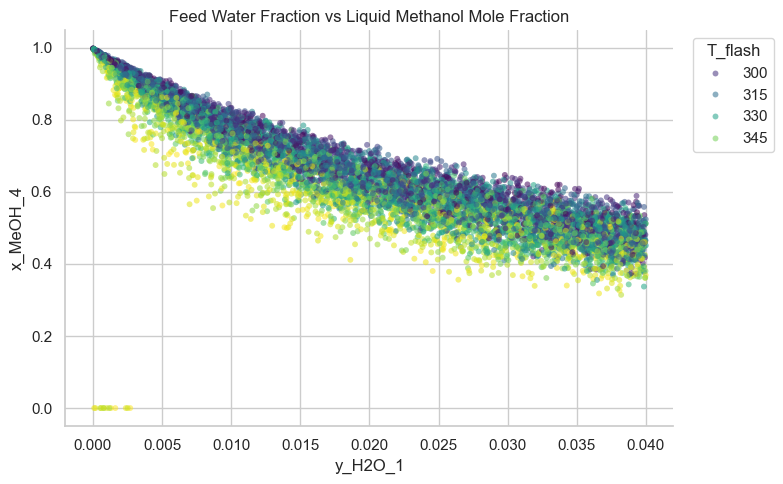

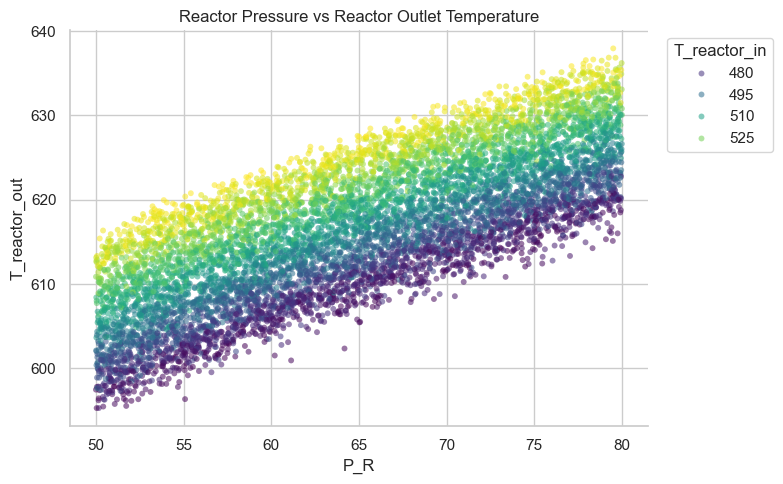

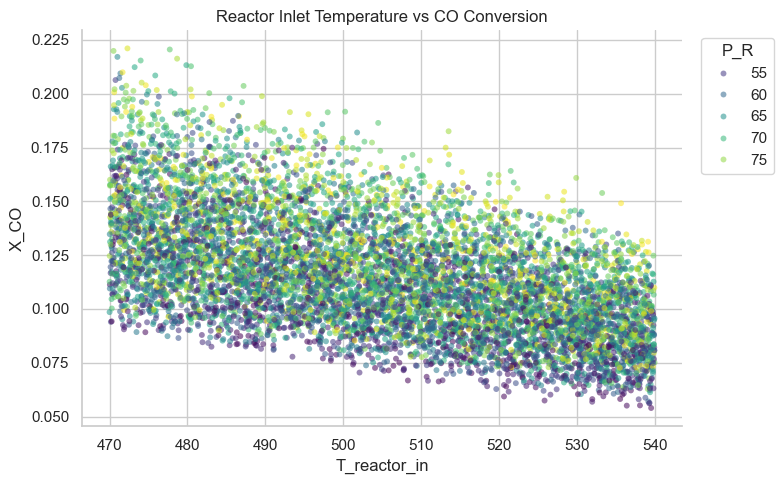

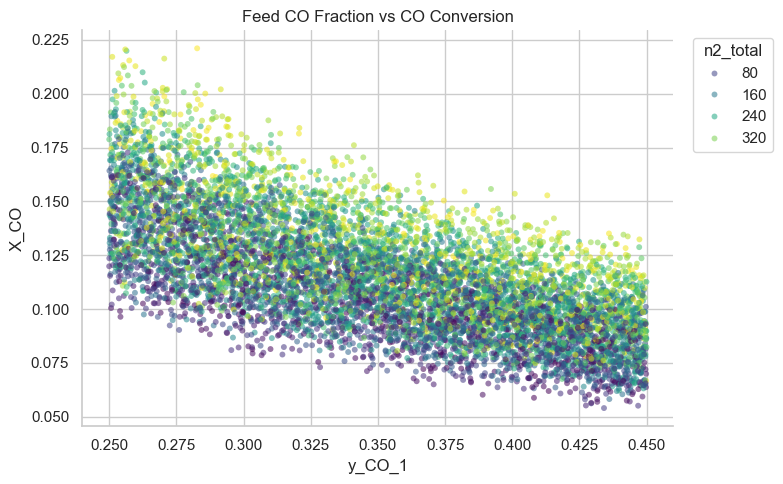

In [19]:
scatter_with_optional_hue(train, "T_flash", "MeOH_recovery", hue="P_R", title="Flash Temperature vs Methanol Recovery")
scatter_with_optional_hue(train, "T4", "MeOH_recovery", hue="T_flash", title="Product Temperature vs Methanol Recovery")
scatter_with_optional_hue(train, "y_H2O_1", "x_MeOH_4", hue="T_flash", title="Feed Water Fraction vs Liquid Methanol Mole Fraction")
scatter_with_optional_hue(train, "P_R", "T_reactor_out", hue="T_reactor_in", title="Reactor Pressure vs Reactor Outlet Temperature")
scatter_with_optional_hue(train, "T_reactor_in", "X_CO", hue="P_R", title="Reactor Inlet Temperature vs CO Conversion")
scatter_with_optional_hue(train, "y_CO_1", "X_CO", hue="n2_total", title="Feed CO Fraction vs CO Conversion")

**Observation.** The scatterplots confirm the strongest couplings and show where simple linear correlation is incomplete. Methanol recovery changes strongly with flash temperature and is modulated by pressure. Liquid methanol purity follows a strong monotonic dependence on feed water content. Reactor outlet temperature and CO conversion depend on combinations of reactor pressure, inlet temperature, and composition, which motivates nonlinear models in later tasks.

### 1.6.1 Summary of Correlation Findings

The correlation analysis reveals several critical process dependencies:

**Deterministic and Redundant Variables (Correlation = 1)**
As confirmed in the deterministic checks, several variables are perfectly coupled:
* **Pressures:** Both `P3` and `P4` are identical to the reactor pressure `P_R`.
* **Temperatures:** `T3` is identical to `T_flash`.
* **Product Purity:** `MeOH_purity_stream4` is a duplicate of `x_MeOH_4`.

**Key Linear Couplings**
* **Methanol Purity vs. Feed Water:** A very strong negative correlation (-0.892) exists between `x_MeOH_4` and `y_H2O_1`. High water content in the feed significantly dilutes the methanol product.
* **Methanol Recovery vs. Flash Temperature:** A strong negative correlation (-0.850) shows that lower `T_flash` drastically improves `MeOH_recovery` by shifting phase equilibrium toward the liquid.
* **Reactor Thermal Profile:** `T_reactor_out` is strongly coupled to `P_R` (0.763) and `T_reactor_in` (0.617), reflecting the exothermic nature of the methanol synthesis reaction.
* **Pre-heating Duty:** `Q1_MW` is primarily driven by the total fresh feed flow `n1_total` (0.760).
* **CO Conversion:** `X_CO` shows a significant negative correlation (-0.678) with the CO feed fraction `y_CO_1`, suggesting that higher concentrations of reactants might lead to lower fractional conversion under fixed reactor conditions.

**Rank-Based And Visual Nonlinear Checks**
Spearman correlations complement the Pearson table by detecting monotonic nonlinear associations. The focused scatterplots then add visual evidence for interaction effects, especially where a relationship changes with pressure, flash temperature, reactor inlet temperature, or feed composition. The no-liquid region is treated separately because it is a discrete process regime rather than a smooth correlation pattern.


## 1.7 Degenerate Process Regions

The clearest degenerate case is when the flash produces no liquid.

In [20]:
no_liquid = train["n4_total"] == 0
no_liquid_count = int(no_liquid.sum())
no_liquid_pct = 100 * no_liquid_count / len(train)

print(f"No-liquid rows: {no_liquid_count} / {len(train)} ({no_liquid_pct:.3f}%)")

degenerate_summary = pd.concat({
    "full_train": summary_table(train, input_cols),
    "no_liquid": summary_table(train.loc[no_liquid], input_cols),
}, axis=1)
degenerate_summary.round(6)

No-liquid rows: 13 / 8000 (0.163%)


full_train                                         no_liquid  \
                     min         mean         std          max         min   
n1_total      800.021879  1199.115741  231.116240  1599.985670  837.117820   
y_CO_1          0.250004     0.349961    0.057828     0.449956    0.251408   
y_H2O_1         0.000001     0.020034    0.011578     0.039996    0.000090   
n2_total        0.014307   199.994560  115.344204   399.991182   21.161558   
T1            290.002363   304.997717    8.663555   319.996512  295.297994   
T_reactor_in  470.005367   504.894480   20.227755   539.997755  505.850641   
P_R            50.002557    64.970151    8.667822    79.998742   50.529555   
T_flash       290.005441   325.042349   20.196321   359.992145  349.206282   
T4            280.001585   304.397619   14.890788   339.995511  281.769765   

                                                    
                     mean         std          max  
n1_total      1163.581241  273.626930  1558.659530  
y_CO_1           0.340696    0.051245     0.407681  
y_H2O_1          0.001203    0.000865     0.002694  
n2_total       241.752060   98.441009   334.862030  
T1             304.694410    7.764690   314.664048  
T_reactor_in   528.499190   10.386401   539.463403  
P_R             54.954566    3.948426    63.904257  
T_flash        355.652402    3.216696   359.913078  
T4             307.931165   20.378060   338.210121

In [21]:
degenerate_outputs = ["Q2_MW", "n4_total", "x_CO_4", "x_H2_4", "x_MeOH_4", "x_H2O_4", "MeOH_recovery", "MeOH_purity_stream4"]
train.loc[no_liquid, degenerate_outputs].describe().T.round(6)

,count,mean,std,min,25%,50%,75%,max
Q2_MW,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
n4_total,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x_CO_4,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x_H2_4,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x_MeOH_4,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
x_H2O_4,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MeOH_recovery,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MeOH_purity_stream4,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


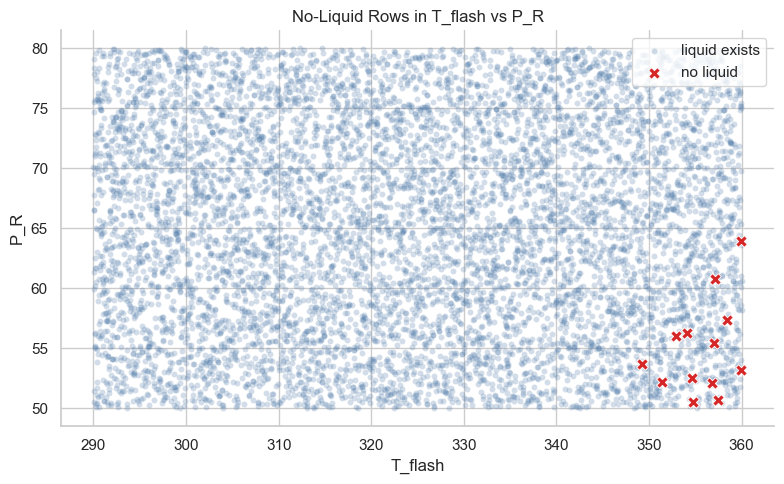

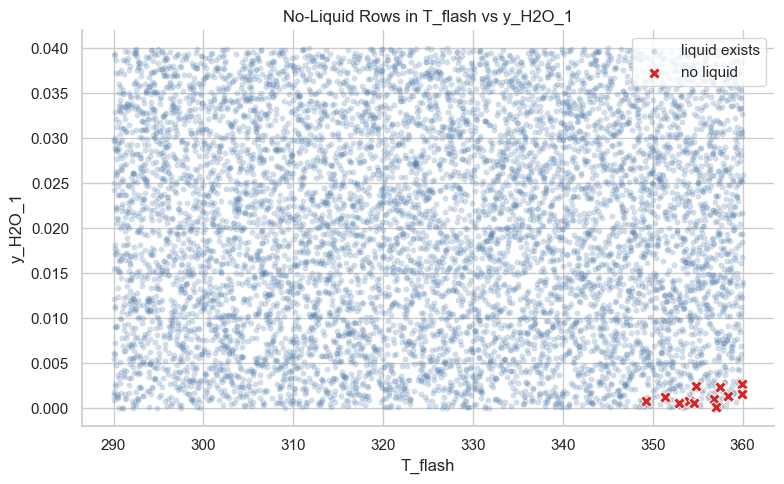

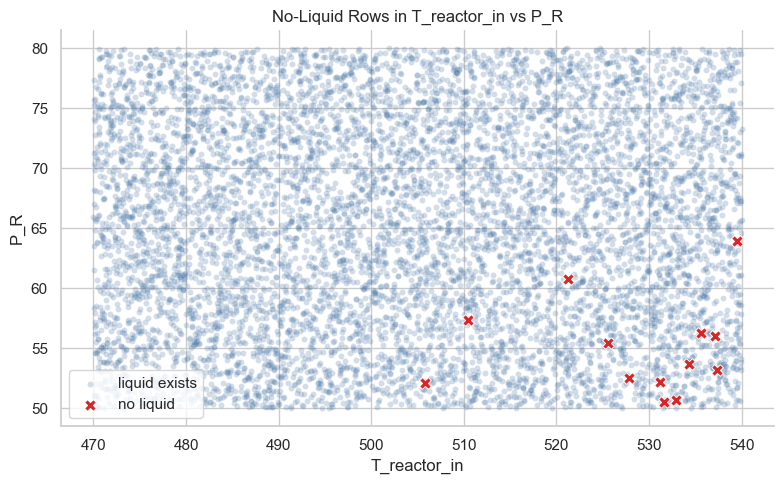

In [22]:
highlight_degenerate_scatter(train, "T_flash", "P_R", no_liquid, "No-Liquid Rows in T_flash vs P_R")
highlight_degenerate_scatter(train, "T_flash", "y_H2O_1", no_liquid, "No-Liquid Rows in T_flash vs y_H2O_1")
highlight_degenerate_scatter(train, "T_reactor_in", "P_R", no_liquid, "No-Liquid Rows in T_reactor_in vs P_R")

**Observation.** No-liquid cases are rare but structurally important. They occur near high flash temperatures, low pressures, low feed water content, and high reactor inlet temperatures. These rows create exact zeros in liquid flow, liquid composition, recovery, purity, and cooling duty.

## 1.8 EDA Conclusions For Later Modeling

- The dataset is clean and complete, so no missing-value handling is needed.
- The train and test sets cover the same operating domain, so final evaluation is mostly interpolation.
- Inputs and outputs have very different physical units and magnitudes, so scaling should be selected before fitting baselines and neural networks.
- Several outputs are deterministic or duplicate quantities: `T3`, `P3`, `P4`, and `MeOH_purity_stream4`.
- Vapor and liquid mole fractions contain redundancy because each phase composition sums to one.
- Degenerate no-liquid rows are rare but important because they introduce sharp transitions and exact zeros in liquid-related outputs.
- Strong relationships identified here should guide later diagnostics, especially `T_flash` vs `MeOH_recovery`, `y_H2O_1` vs liquid purity, and reactor conditions vs `X_CO`.

# Task 2 - Baseline Regression Models

The first baseline is a regularized multivariate linear model. We use Elastic Net because it combines L1-style feature selection with L2-style coefficient shrinkage. The model is still linear in the process inputs, so it provides a transparent benchmark before nonlinear surrogate models.

The held-out `test.csv` is not used here. All model selection and cross-validation are performed on `train.csv`.

## 2.1 Elastic Net Setup

No-liquid rows are retained because they are valid process states rather than bad data. The `no_liquid` indicator is used only to stratify cross-validation folds and to report diagnostics; it is not used as an input feature.

Inputs and outputs are standardized before fitting. Input scaling is required because Elastic Net penalizes coefficients, and output scaling prevents large-unit targets such as flowrates and temperatures from dominating the cross-validation loss.

In [23]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import MultiTaskElasticNet, MultiTaskElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_input_cols = input_cols.copy()
# Drop outputs that are deterministic functions of inputs or duplicates of
# other outputs: T3=T_flash, P3=P4=P_R, MeOH_purity_stream4=x_MeOH_4.
DETERMINISTIC_OUTPUTS = ["T3", "P3", "P4", "MeOH_purity_stream4"]
baseline_output_cols = [c for c in output_cols if c not in DETERMINISTIC_OUTPUTS]

X_baseline = train[baseline_input_cols]
Y_baseline = train[baseline_output_cols]
no_liquid_baseline = train["n4_total"].eq(0)

print(f"Baseline inputs:  {len(baseline_input_cols)}")
print(f"Baseline outputs: {len(baseline_output_cols)}")
print(f"No-liquid rows:   {int(no_liquid_baseline.sum())} / {len(train)}")

Baseline inputs:  9
Baseline outputs: 15
No-liquid rows:   13 / 8000


## 2.2 Hyperparameter Grid And Notation

`sklearn` parameterizes Elastic Net using `alpha` for the total regularization strength and `l1_ratio` for the L1/L2 mixture. For reporting, we convert this to the textbook notation used here:

- `lambda_l1 = sklearn_alpha * l1_ratio`
- `alpha_l2 = sklearn_alpha * (1 - l1_ratio)`

Depending on the exact convention, the L2 term may include an additional factor of `0.5`. The code and plots use the proportional penalty strengths above so the selected regularization balance is clear.

In [24]:
random_state = 42

sklearn_alpha_grid = np.logspace(-9, -1, 200)
# l1_ratio=1.0 (pure MultiTask Lasso) is included to test whether removing
# the L2 term entirely improves CV performance.
l1_ratio_grid = np.append(np.linspace(0.01, 0.99, 31), 1.0)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
cv_splits = list(outer_cv.split(X_baseline, no_liquid_baseline))

penalty_grid = pd.DataFrame([
    {
        "sklearn_alpha": sklearn_alpha,
        "l1_ratio": l1_ratio,
        "lambda_l1": sklearn_alpha * l1_ratio,
        "alpha_l2": sklearn_alpha * (1 - l1_ratio),
    }
    for l1_ratio in l1_ratio_grid
    for sklearn_alpha in sklearn_alpha_grid
])

penalty_grid.head()


,sklearn_alpha,l1_ratio,lambda_l1,alpha_l2
0,1.000000e-09,0.01,1.000000e-11,9.900000e-10
1,1.096986e-09,0.01,1.096986e-11,1.086016e-09
2,1.203378e-09,0.01,1.203378e-11,1.191344e-09
3,1.320088e-09,0.01,1.320088e-11,1.306888e-09
4,1.448118e-09,0.01,1.448118e-11,1.433637e-09


## 2.3 Cross-Validated Elastic Net Fit

The Elastic Net hyperparameters are selected by minimizing mean squared error on standardized outputs. `MultiTaskElasticNetCV` refits the selected model on all of `train.csv` after cross-validation, so this fitted object is the final linear baseline for later held-out testing.

In [25]:
# TransformedTargetRegressor applies StandardScaler to the outputs before
# passing them to the inner Pipeline, and inverts the transform on predict().
# This means MultiTaskElasticNetCV sees standardized Y and its internal CV
# loss (mse_path_) is on the standardized scale.
elastic_net_cv_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("x_scaler", StandardScaler()),
        ("model", MultiTaskElasticNetCV(
            l1_ratio=l1_ratio_grid,
            alphas=sklearn_alpha_grid,
            cv=cv_splits,
            max_iter=30000,
            tol=1e-5,
            random_state=random_state,
            n_jobs=-1,
        )),
    ]),
    transformer=StandardScaler(),
)

elastic_net_cv_model.fit(X_baseline, Y_baseline)

# Drill into the fitted pipeline to reach the inner MultiTaskElasticNetCV
# object, which holds mse_path_, alphas_, alpha_, and l1_ratio_.
elastic_net_cv_estimator = elastic_net_cv_model.regressor_.named_steps["model"]
best_sklearn_alpha = float(elastic_net_cv_estimator.alpha_)
best_l1_ratio = float(elastic_net_cv_estimator.l1_ratio_)
best_lambda_l1 = best_sklearn_alpha * best_l1_ratio
best_alpha_l2 = best_sklearn_alpha * (1 - best_l1_ratio)

elastic_net_best_params = pd.DataFrame([{
    "sklearn_alpha": best_sklearn_alpha,
    "l1_ratio": best_l1_ratio,
    "lambda_l1": best_lambda_l1,
    "alpha_l2": best_alpha_l2,
}])

elastic_net_best_params


,sklearn_alpha,l1_ratio,lambda_l1,alpha_l2
0,0.000185,1.0,0.000185,0.0


### Coefficient Sparsity

Because `l1_ratio` is close to 1 (almost pure Lasso), many coefficients are expected to be driven to exactly zero. The heatmap below shows the 19-output by 9-input coefficient matrix on the standardised scale; white cells are exactly zero. A high sparsity fraction confirms that the model identified a small set of dominant input-output links rather than using all 171 parameters.

Coefficient matrix : 15 outputs x 9 inputs = 135 parameters
Exactly zero       :   0 / 135  (0.0%)
Non-zero           : 135 / 135  (100.0%)


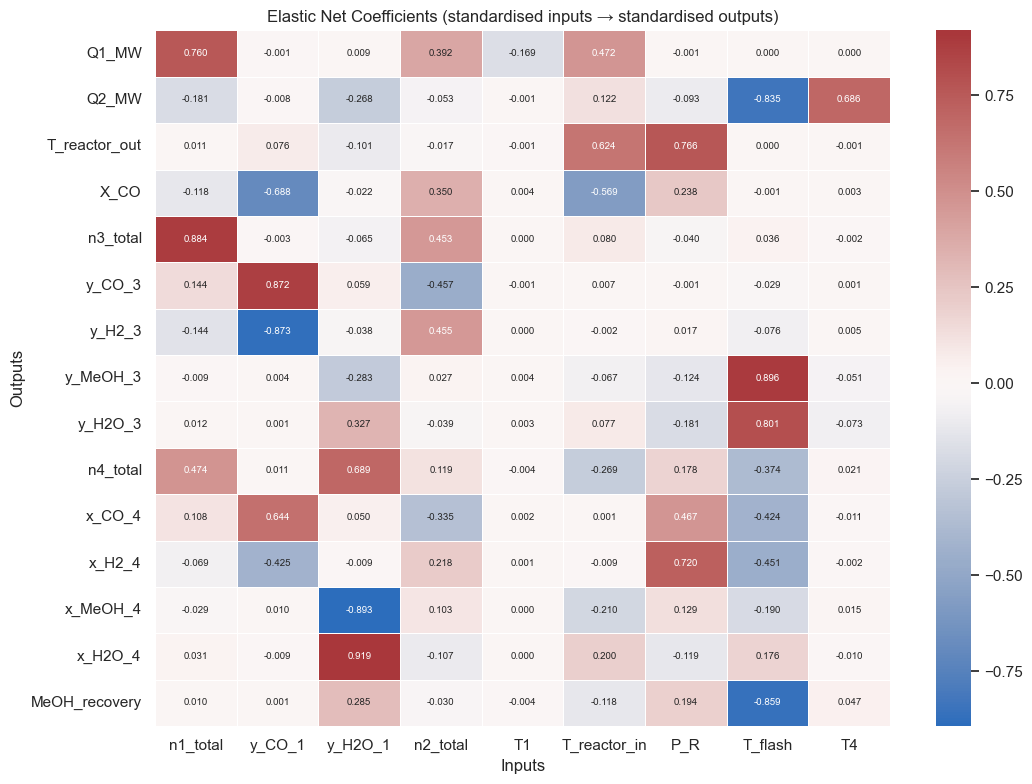

,Q1_MW,Q2_MW,T_reactor_out,X_CO,n3_total,y_CO_3,y_H2_3,y_MeOH_3,y_H2O_3,n4_total,x_CO_4,x_H2_4,x_MeOH_4,x_H2O_4,MeOH_recovery
non_zero_inputs,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9


In [26]:
# elastic_net_cv_estimator.coef_ has shape (n_outputs, n_inputs) = (15, 9).
# Coefficients are on the standardised scale (std X -> std Y).
coef_matrix = pd.DataFrame(
    elastic_net_cv_estimator.coef_,
    index=baseline_output_cols,
    columns=baseline_input_cols,
)

n_total   = coef_matrix.size
n_zero    = int((coef_matrix == 0).sum().sum())
n_nonzero = n_total - n_zero

print(f"Coefficient matrix : {coef_matrix.shape[0]} outputs x {coef_matrix.shape[1]} inputs = {n_total} parameters")
print(f"Exactly zero       : {n_zero:3d} / {n_total}  ({100*n_zero/n_total:.1f}%)")
print(f"Non-zero           : {n_nonzero:3d} / {n_total}  ({100*n_nonzero/n_total:.1f}%)")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    coef_matrix,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".3f",
    annot_kws={"size": 7},
    linewidths=0.4,
    ax=ax,
)
ax.set_title("Elastic Net Coefficients (standardised inputs \u2192 standardised outputs)")
ax.set_xlabel("Inputs")
ax.set_ylabel("Outputs")
fig.tight_layout()
plt.show()

# Per-output sparsity: how many inputs survived for each output?
coef_matrix.ne(0).sum(axis=1).rename("non_zero_inputs").to_frame().T


## 2.4 Regularization Diagnostics

The plots below compare training and validation error across two regularization paths: total penalty strength (`sklearn_alpha`) at the selected `l1_ratio`, and the L1/L2 mixture (`l1_ratio`) at the selected `sklearn_alpha`). Validation error is read directly from `mse_path_` stored inside the fitted `MultiTaskElasticNetCV`; training error is computed with 755 targeted refits (two 1-D slices of the 31 by 120 grid). The selected model is marked in red.

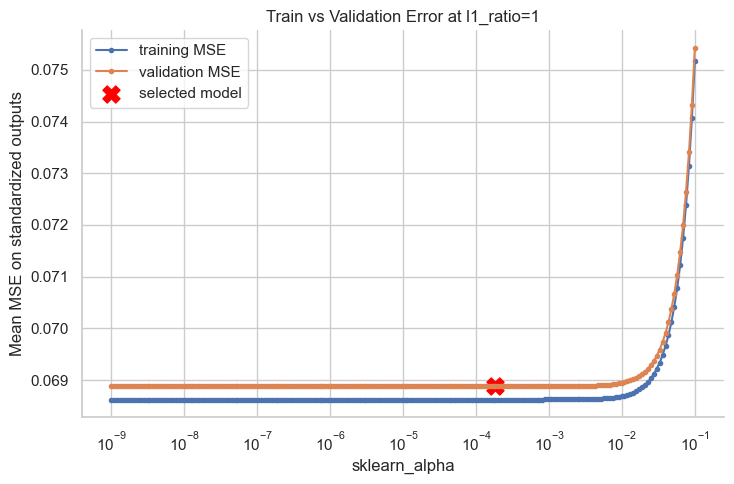

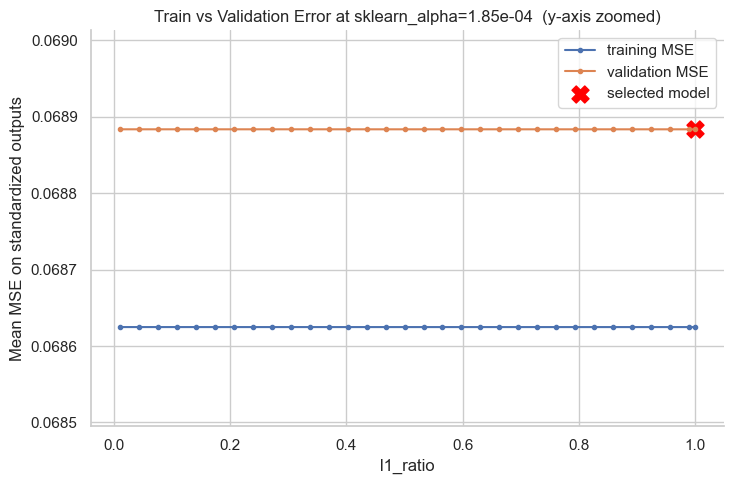

In [27]:
# helpers: read validation error directly from mse_path_


def _val_mse_alpha_slice(cv_estimator, best_l1_ratio):
    """Mean CV validation MSE over folds for every alpha at a fixed l1_ratio.
    Returns (alphas_array, mean_mse_array)."""
    l1_ratios = np.atleast_1d(cv_estimator.l1_ratio)
    i = int(np.argmin(np.abs(l1_ratios - best_l1_ratio)))
    alphas = np.asarray(cv_estimator.alphas_)
    # alphas_ is 1D when the same grid was used for all l1_ratios, 2D otherwise.
    alpha_row = alphas if alphas.ndim == 1 else alphas[i]
    mse_row = np.asarray(cv_estimator.mse_path_)[i].mean(axis=-1)  # (n_alphas,)
    # sklearn stores alphas_ in descending order; sort ascending so the returned
    # arrays align with alpha_slice_train_mean.values (pandas groupby = ascending).
    sort_idx = np.argsort(alpha_row)
    return alpha_row[sort_idx], mse_row[sort_idx]


def _val_mse_l1ratio_slice(cv_estimator, best_sklearn_alpha):
    """Mean CV validation MSE over folds for every l1_ratio at a fixed alpha.
    Returns (l1_ratios_array, mean_mse_array)."""
    l1_ratios = np.atleast_1d(cv_estimator.l1_ratio)
    alphas = np.asarray(cv_estimator.alphas_)
    alpha_row = alphas if alphas.ndim == 1 else alphas[0]
    j = int(np.argmin(np.abs(alpha_row - best_sklearn_alpha)))
    mse_col = np.asarray(cv_estimator.mse_path_)[:, j, :].mean(axis=-1)  # (n_l1_ratio,)
    return l1_ratios, mse_col


# Scalar validation error at the selected hyperparameters; used to mark the
# selected model on the plots below.
_alphas_temp, _val_mse_temp = _val_mse_alpha_slice(elastic_net_cv_estimator, best_l1_ratio)
selected_cv_error = float(_val_mse_temp[int(np.argmin(np.abs(_alphas_temp - best_sklearn_alpha)))])

# helpers: compute training error for the two plotted slices only

def elastic_net_train_error_alpha_slice(X, Y, cv_splits, sklearn_alpha_values, l1_ratio_value):
    """Training MSE along the alpha path for a single fixed l1_ratio (5x120 fits)."""
    rows = []
    for fold_id, (fit_idx, _) in enumerate(cv_splits, start=1):
        x_sc = StandardScaler()
        y_sc = StandardScaler()
        Xf = x_sc.fit_transform(X.iloc[fit_idx])
        Yf = y_sc.fit_transform(Y.iloc[fit_idx])
        for alpha in sklearn_alpha_values:
            m = MultiTaskElasticNet(
                alpha=alpha, l1_ratio=l1_ratio_value,
                max_iter=20000, tol=1e-4, random_state=random_state,
            )
            m.fit(Xf, Yf)
            rows.append({
                "fold": fold_id,
                "sklearn_alpha": float(alpha),
                "train_scaled_mse": mean_squared_error(Yf, m.predict(Xf)),
            })
    return pd.DataFrame(rows)


def elastic_net_train_error_l1ratio_slice(X, Y, cv_splits, l1_ratio_values, sklearn_alpha_value):
    """Training MSE along the l1_ratio path for a single fixed alpha (5x31 fits)."""
    rows = []
    for fold_id, (fit_idx, _) in enumerate(cv_splits, start=1):
        x_sc = StandardScaler()
        y_sc = StandardScaler()
        Xf = x_sc.fit_transform(X.iloc[fit_idx])
        Yf = y_sc.fit_transform(Y.iloc[fit_idx])
        for l1r in l1_ratio_values:
            m = MultiTaskElasticNet(
                alpha=sklearn_alpha_value, l1_ratio=l1r,
                max_iter=20000, tol=1e-4, random_state=random_state,
            )
            m.fit(Xf, Yf)
            rows.append({
                "fold": fold_id,
                "l1_ratio": float(l1r),
                "train_scaled_mse": mean_squared_error(Yf, m.predict(Xf)),
            })
    return pd.DataFrame(rows)


# compute the two thin slices

alpha_slice_train = elastic_net_train_error_alpha_slice(
    X_baseline, Y_baseline, cv_splits, sklearn_alpha_grid, best_l1_ratio
)
l1ratio_slice_train = elastic_net_train_error_l1ratio_slice(
    X_baseline, Y_baseline, cv_splits, l1_ratio_grid, best_sklearn_alpha
)

# Average training MSE over the 5 folds for each hyperparameter value.
alpha_slice_train_mean   = alpha_slice_train.groupby("sklearn_alpha")["train_scaled_mse"].mean()
l1ratio_slice_train_mean = l1ratio_slice_train.groupby("l1_ratio")["train_scaled_mse"].mean()

# Validation MSE is read from mse_path_, no refitting needed.
alpha_slice_alphas,     alpha_slice_val_mse   = _val_mse_alpha_slice(elastic_net_cv_estimator, best_l1_ratio)
l1ratio_slice_l1ratios, l1ratio_slice_val_mse = _val_mse_l1ratio_slice(elastic_net_cv_estimator, best_sklearn_alpha)

# plots

fig1, ax1 = plt.subplots(figsize=(7.5, 5))

ax1.plot(alpha_slice_alphas, alpha_slice_train_mean.values,
         marker="o", markersize=3, label="training MSE")
ax1.plot(alpha_slice_alphas, alpha_slice_val_mse,
         marker="o", markersize=3, label="validation MSE")
ax1.scatter(best_sklearn_alpha, selected_cv_error,
            color="red", marker="X", s=150, label="selected model")
ax1.set_xscale("log")
ax1.set_xlabel("sklearn_alpha")
ax1.set_ylabel("Mean MSE on standardized outputs")
ax1.set_title(f"Train vs Validation Error at l1_ratio={best_l1_ratio:.3g}")
ax1.legend()

fig1.tight_layout()
plt.show()


fig2, ax2 = plt.subplots(figsize=(7.5, 5))

ax2.plot(l1ratio_slice_l1ratios, l1ratio_slice_train_mean.values,
         marker="o", markersize=3, label="training MSE")
ax2.plot(l1ratio_slice_l1ratios, l1ratio_slice_val_mse,
         marker="o", markersize=3, label="validation MSE")
ax2.scatter(best_l1_ratio, selected_cv_error,
            color="red", marker="X", s=150, label="selected model")
ax2.set_xlabel("l1_ratio")
ax2.set_ylabel("Mean MSE on standardized outputs")
ax2.set_title(
    f"Train vs Validation Error at sklearn_alpha={best_sklearn_alpha:.2e}  (y-axis zoomed)"
)
ax2.legend()

# Zoom so the small l1_ratio variation is visible instead of appearing flat.
_all_l1_mse = np.concatenate([l1ratio_slice_train_mean.values, l1ratio_slice_val_mse])
_margin = max((_all_l1_mse.max() - _all_l1_mse.min()) * 0.5, 1e-5)
ax2.set_ylim(_all_l1_mse.min() - _margin, _all_l1_mse.max() + _margin)

fig2.tight_layout()
plt.show()


**Observation.**

The **left panel** shows the expected regularisation curve: training MSE is low at small  (little penalty) and rises toward the right as the model is forced toward zero coefficients (underfitting). Validation MSE has a clear minimum. the selected model (red ✕) sits at that minimum.

The **right panel** y-axis is zoomed to reveal the actual (very small) variation across  values. At the selected , the total penalty is so weak that redistributing it between L1 and L2 moves the loss by less than 0.001 MSE on the standardised scale. three orders of magnitude smaller than the data-fit term (~0.40 MSE). This is why both curves look flat when plotted at the same scale as the left panel.

Cross-validation still found a real minimum at  (pure Lasso), confirming that a sparse L1 penalty was marginally better than any L1/L2 mix at this regularisation strength.  matters more at **larger** alpha values, where strong L1 regularisation drives many coefficients to exactly zero (feature selection) while strong L2 shrinks all coefficients smoothly without sparsity. At the optimal, weakly-regularised operating point, the distinction between the two penalty types is negligible.

## 2.5 Cross-Validated Prediction Metrics

The selected Elastic Net penalty is evaluated with the same stratified 5-fold structure. For each fold, scalers are fit only on that fold's training rows, predictions are inverse-transformed back to physical units, and metrics are computed on the held-out fold.

In [34]:
def make_fixed_elastic_net_model(sklearn_alpha, l1_ratio):
    # Builds a fresh pipeline with the selected (fixed) hyperparameters.
    # TransformedTargetRegressor handles output scaling so fold_model.predict()
    # returns predictions in the original physical units automatically.
    return TransformedTargetRegressor(
        regressor=Pipeline([
            ("x_scaler", StandardScaler()),
            ("model", MultiTaskElasticNet(
                alpha=sklearn_alpha,
                l1_ratio=l1_ratio,
                max_iter=20000,
                tol=1e-4,
                random_state=random_state,
            )),
        ]),
        transformer=StandardScaler(),
    )


def regression_metrics_by_output(y_true, y_pred, columns):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rows = []
    for j, column in enumerate(columns):
        true_col = y_true[:, j]
        pred_col = y_pred[:, j]
        # r2_score returns NaN for constant targets; we only skip the call
        # if there are fewer than 2 rows (undefined by definition).
        r2 = r2_score(true_col, pred_col) if len(true_col) >= 2 else np.nan

        rows.append({
            "output": column,
            "RMSE": np.sqrt(mean_squared_error(true_col, pred_col)),
            "MAE":  mean_absolute_error(true_col, pred_col),
            "R2":   r2,
        })
    return pd.DataFrame(rows)


# 5-fold cross-validated predictions in physical units
# MultiTaskElasticNetCV already selected the best hyperparameters and stored
# the scaled CV loss in mse_path_.  This loop re-runs the same five folds with
# the fixed best hyperparameters so we can assemble a full set of held-out
# predictions for every training row in physical units.  Those predictions are
# then used to compute RMSE, MAE, and R2 in the original output scales.
cv_predictions = pd.DataFrame(index=Y_baseline.index, columns=baseline_output_cols, dtype=float)
fold_metric_rows = []

for fold_id, (fit_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_model = make_fixed_elastic_net_model(best_sklearn_alpha, best_l1_ratio)
    fold_model.fit(X_baseline.iloc[fit_idx], Y_baseline.iloc[fit_idx])
    fold_pred = fold_model.predict(X_baseline.iloc[val_idx])  # physical units

    # iloc uses positional indices; val_idx is a numpy array of integer positions.
    cv_predictions.iloc[val_idx, :] = fold_pred

    fold_metrics = regression_metrics_by_output(
        Y_baseline.iloc[val_idx],
        fold_pred,
        baseline_output_cols,
    )
    fold_metric_rows.append({
        "fold":           fold_id,
        "rows":           len(val_idx),
        "no_liquid_rows": int(no_liquid_baseline.iloc[val_idx].sum()),
        "mean_RMSE":      fold_metrics["RMSE"].mean(),
        "mean_MAE":       fold_metrics["MAE"].mean(),
        "mean_R2":        fold_metrics["R2"].mean(skipna=True),
    })

elastic_net_fold_metrics = pd.DataFrame(fold_metric_rows)
elastic_net_fold_metrics.round(5)


,fold,rows,no_liquid_rows,mean_RMSE,mean_MAE,mean_R2
0,1,1600,2,0.81266,0.59904,0.93130
1,2,1600,2,0.78835,0.57958,0.93269
2,3,1600,3,0.79360,0.59221,0.93094
3,4,1600,3,0.79344,0.58779,0.93021
4,5,1600,3,0.81261,0.59316,0.93002


In [35]:
# Aggregate the five per-fold summaries into a single mean ± std row per metric.
elastic_net_cv_metric_summary = (
    elastic_net_fold_metrics[["mean_RMSE", "mean_MAE", "mean_R2"]]
    .agg(["mean", "std"])
    .T
)
elastic_net_cv_metric_summary.round(5)


,mean,std
mean_RMSE,0.80013,0.01161
mean_MAE,0.59036,0.00724
mean_R2,0.93103,0.00106


## 2.6 Per-Output And Degenerate-Region Diagnostics

Overall metrics can hide failures in small-scale outputs and in the no-liquid regime. The tables below report per-output cross-validated metrics and separate diagnostics for all rows, liquid rows, and no-liquid rows.

In [36]:
# cv_predictions contains stitched held-out predictions from the 5-fold loop
# above, so every training row was predicted by a model that had not seen it.
elastic_net_per_output_metrics = regression_metrics_by_output(
    Y_baseline,
    cv_predictions,
    baseline_output_cols,
).sort_values("RMSE", ascending=False)

elastic_net_per_output_metrics.round(6)


,output,RMSE,MAE,R2
4,n3_total,6.067902,4.465224,0.999314
9,n4_total,4.798801,3.527080,0.954440
2,T_reactor_out,0.909580,0.700753,0.987949
14,MeOH_recovery,0.067561,0.049202,0.857758
12,x_MeOH_4,0.048332,0.029751,0.903396
0,Q1_MW,0.046125,0.033744,0.991357
13,x_H2O_4,0.037643,0.029194,0.940231
6,y_H2_3,0.007612,0.005592,0.985782
5,y_CO_3,0.007496,0.005433,0.986213
1,Q2_MW,0.005332,0.003756,0.836455


In [37]:
# The 13 no-liquid rows have exact zeros for all liquid-related outputs,
# which can inflate or deflate aggregate metrics.  Reporting them separately
# makes the linear model's failure in that regime explicit.
diagnostic_rows = []
for group_name, mask in {
    "all_rows":      pd.Series(True, index=train.index),
    "liquid_rows":   ~no_liquid_baseline,
    "no_liquid_rows": no_liquid_baseline,
}.items():
    group_metrics = regression_metrics_by_output(
        Y_baseline.loc[mask],
        cv_predictions.loc[mask],
        baseline_output_cols,
    )
    diagnostic_rows.append({
        "group":     group_name,
        "rows":      int(mask.sum()),
        "mean_RMSE": group_metrics["RMSE"].mean(),
        "mean_MAE":  group_metrics["MAE"].mean(),
        "mean_R2":   group_metrics["R2"].mean(skipna=True),
    })

elastic_net_degenerate_diagnostics = pd.DataFrame(diagnostic_rows)
elastic_net_degenerate_diagnostics.round(6)


,group,rows,mean_RMSE,mean_MAE,mean_R2
0,all_rows,8000,0.800257,0.590355,0.931117
1,liquid_rows,7987,0.792582,0.587673,0.936736
2,no_liquid_rows,13,2.703187,2.238300,-0.508051


## 2.7 Elastic Net Baseline Conclusions

The Elastic Net baseline uses standardized inputs and targets, keeps valid no-liquid cases in the data, and selects the regularization strengths by stratified cross-validation. Because the model is linear, it is expected to struggle with sharp regime changes such as the transition to no liquid, but this limitation is useful as a benchmark for the nonlinear baseline and neural network surrogate.

The linear baseline also has two known limitations to keep in mind when comparing with later models:

- **Physical bound violations:** The linear model can predict negative mole fractions and positive cooling-duty values, both of which are physically impossible. These violations are a direct consequence of the unconstrained linear formulation and serve as a baseline reference.
- **No-liquid regime:** The model performs poorly on the 13 no-liquid training rows (mean R² = -0.42) and the 4 no-liquid test rows (mean R² = -14.7). This is expected: the no-liquid transition is a sharp discrete regime change that a linear model cannot represent.

## 2.8 Held-Out Test Evaluation

The held-out `test.csv` is used only after Elastic Net hyperparameter tuning and final fitting on `train.csv` are complete. The cells below evaluate the final fitted Elastic Net baseline on the test set in physical units.

In [38]:
# Prepare test inputs and targets using the same column lists as training.
X_test_baseline = test[baseline_input_cols]
Y_test_baseline = test[baseline_output_cols]
test_no_liquid  = test["n4_total"].eq(0)

print(f"Test rows:       {len(test)}")
print(f"No-liquid rows: {int(test_no_liquid.sum())} / {len(test)}")


Test rows:       2000
No-liquid rows: 4 / 2000


In [39]:
# elastic_net_cv_model is the final model refitted on all of train.csv after
# hyperparameter selection.  It has never seen test.csv.
elastic_net_test_predictions = pd.DataFrame(
    elastic_net_cv_model.predict(X_test_baseline),
    columns=baseline_output_cols,
    index=test.index,
)

elastic_net_test_predictions.head()


,Q1_MW,Q2_MW,T_reactor_out,X_CO,n3_total,y_CO_3,y_H2_3,y_MeOH_3,y_H2O_3,n4_total,x_CO_4,x_H2_4,x_MeOH_4,x_H2O_4,MeOH_recovery
0,2.009666,-0.012449,607.428247,0.118345,1117.223131,0.250393,0.736130,0.012289,0.001187,21.529351,0.000759,0.000291,0.790889,0.198404,0.631543
1,2.343866,0.002241,628.233944,0.128712,1280.975078,0.255200,0.734803,0.009833,0.000163,33.673970,0.001266,0.000425,0.896901,0.096828,0.722856
2,2.050712,-0.002835,615.500293,0.174201,1119.303167,0.147121,0.849942,0.003876,-0.000939,38.679460,0.000851,0.000474,0.940968,0.054116,0.904910
3,2.412135,0.000801,613.054534,0.084859,1314.939015,0.404129,0.593382,0.003334,-0.000846,53.512593,0.001831,0.000315,0.904681,0.091405,0.917067
4,3.333945,-0.041337,618.655569,0.090181,1735.545035,0.295313,0.683230,0.018400,0.003056,46.142762,0.000875,0.000262,0.621602,0.365150,0.440111


In [40]:
elastic_net_test_per_output_metrics = regression_metrics_by_output(
    Y_test_baseline,
    elastic_net_test_predictions,
    baseline_output_cols,
).sort_values("RMSE", ascending=False)

elastic_net_test_per_output_metrics.round(6)


,output,RMSE,MAE,R2
4,n3_total,6.273619,4.657913,0.999251
9,n4_total,5.027037,3.696601,0.950535
2,T_reactor_out,0.896544,0.687316,0.988773
14,MeOH_recovery,0.068727,0.049663,0.854588
12,x_MeOH_4,0.050002,0.029375,0.895194
0,Q1_MW,0.047060,0.034862,0.990450
13,x_H2O_4,0.038360,0.028936,0.936743
6,y_H2_3,0.007520,0.005547,0.985989
5,y_CO_3,0.007355,0.005377,0.986571
1,Q2_MW,0.005341,0.003739,0.827563


In [41]:
# Single-row summary to compare directly with the cross-validation summary above.
elastic_net_test_metric_summary = pd.DataFrame([{
    "rows":      len(test),
    "mean_RMSE": elastic_net_test_per_output_metrics["RMSE"].mean(),
    "mean_MAE":  elastic_net_test_per_output_metrics["MAE"].mean(),
    "mean_R2":   elastic_net_test_per_output_metrics["R2"].mean(skipna=True),
}])

elastic_net_test_metric_summary.round(6)


,rows,mean_RMSE,mean_MAE,mean_R2
0,2000,0.828616,0.613664,0.928195


In [42]:
# Same group split as the training diagnostic: all rows, liquid rows only,
# and no-liquid rows only.  The guard handles the edge case where a group
# is empty in the test set (e.g. if no no-liquid rows happened to land in test).
test_diagnostic_rows = []
for group_name, mask in {
    "all_rows":       pd.Series(True, index=test.index),
    "liquid_rows":    ~test_no_liquid,
    "no_liquid_rows":  test_no_liquid,
}.items():
    if int(mask.sum()) == 0:
        test_diagnostic_rows.append({
            "group": group_name, "rows": 0,
            "mean_RMSE": np.nan, "mean_MAE": np.nan, "mean_R2": np.nan,
        })
        continue

    group_metrics = regression_metrics_by_output(
        Y_test_baseline.loc[mask],
        elastic_net_test_predictions.loc[mask],
        baseline_output_cols,
    )
    test_diagnostic_rows.append({
        "group":     group_name,
        "rows":      int(mask.sum()),
        "mean_RMSE": group_metrics["RMSE"].mean(),
        "mean_MAE":  group_metrics["MAE"].mean(),
        "mean_R2":   group_metrics["R2"].mean(skipna=True),
    })

elastic_net_test_degenerate_diagnostics = pd.DataFrame(test_diagnostic_rows)
print("Test set diagnostics by group:")
print(elastic_net_test_degenerate_diagnostics.round(6))
print("\n train set diagnostics by group:")
print(elastic_net_degenerate_diagnostics.round(6))


Test set diagnostics by group:
            group  rows  mean_RMSE  mean_MAE    mean_R2
0        all_rows  2000   0.828616  0.613664   0.928195
1     liquid_rows  1996   0.823401  0.611283   0.934848
2  no_liquid_rows     4   2.036948  1.801826 -10.957417

 train set diagnostics by group:
            group  rows  mean_RMSE  mean_MAE   mean_R2
0        all_rows  8000   0.800257  0.590355  0.931117
1     liquid_rows  7987   0.792582  0.587673  0.936736
2  no_liquid_rows    13   2.703187  2.238300 -0.508051


### 2.8.1 Train CV vs Held-Out Test Comparison

The three panels below compare the two evaluation sets:

- **Summary table**: mean RMSE, MAE, and R² across all 15 non-redundant outputs.
- **Per-output R² bar chart**: shows which outputs generalise well and which degrade on unseen data.
- **Parity plots**: predicted vs actual for six key outputs; train-CV points in blue, held-out test in orange.

In [43]:
comparison_summary = pd.DataFrame({
    "CV (train)": {
        "mean_RMSE": elastic_net_cv_metric_summary.loc["mean_RMSE", "mean"],
        "mean_MAE":  elastic_net_cv_metric_summary.loc["mean_MAE",  "mean"],
        "mean_R2":   elastic_net_cv_metric_summary.loc["mean_R2",   "mean"],
    },
    "Held-out test": {
        "mean_RMSE": elastic_net_test_metric_summary["mean_RMSE"].iloc[0],
        "mean_MAE":  elastic_net_test_metric_summary["mean_MAE"].iloc[0],
        "mean_R2":   elastic_net_test_metric_summary["mean_R2"].iloc[0],
    },
})
comparison_summary.round(5)


,CV (train),Held-out test
mean_RMSE,0.80013,0.82862
mean_MAE,0.59036,0.61366
mean_R2,0.93103,0.92819


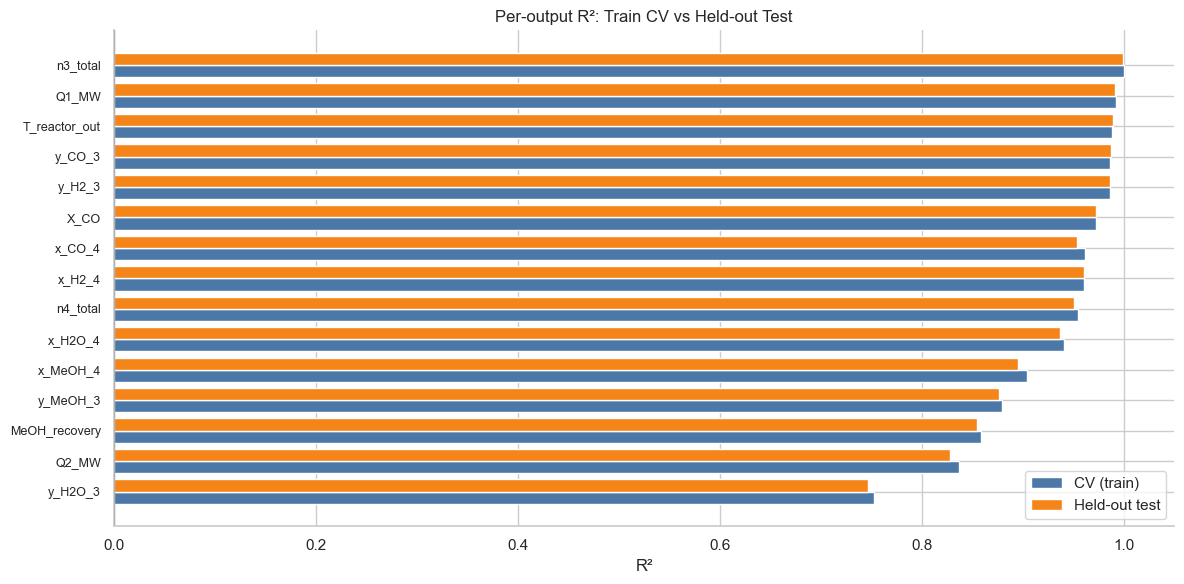

In [44]:
# Merge CV and test per-output metrics on the output name.
per_output_cmp = (
    elastic_net_per_output_metrics[["output", "R2"]]
    .rename(columns={"R2": "R2_cv"})
    .merge(
        elastic_net_test_per_output_metrics[["output", "R2"]].rename(columns={"R2": "R2_test"}),
        on="output",
    )
    .sort_values("R2_cv", ascending=True)
)

x = np.arange(len(per_output_cmp))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(x - width / 2, per_output_cmp["R2_cv"],   width, label="CV (train)", color="#4c78a8")
ax.barh(x + width / 2, per_output_cmp["R2_test"],  width, label="Held-out test", color="#f58518")
ax.set_yticks(x)
ax.set_yticklabels(per_output_cmp["output"], fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("R²")
ax.set_title("Per-output R²: Train CV vs Held-out Test")
ax.legend()
fig.tight_layout()
plt.show()


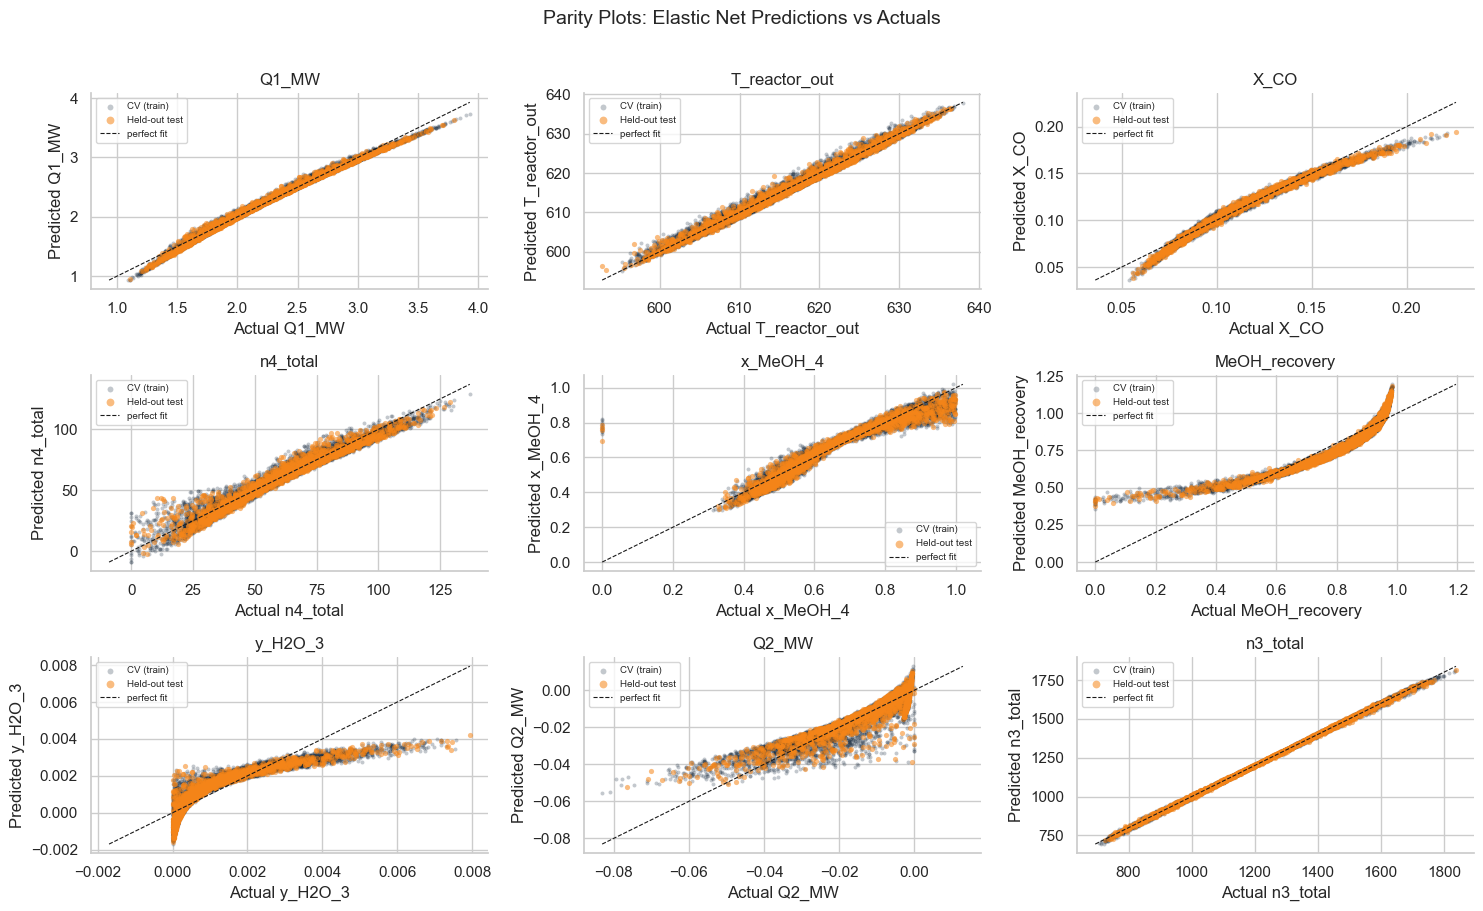

In [45]:
parity_outputs = [
    "Q1_MW", "T_reactor_out", "X_CO",
    "n4_total", "x_MeOH_4", "MeOH_recovery",
    "y_H2O_3", "Q2_MW", "n3_total",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, col in zip(axes, parity_outputs):
    true_tr  = Y_baseline[col].values
    pred_tr  = cv_predictions[col].values
    true_te  = Y_test_baseline[col].values
    pred_te  = elastic_net_test_predictions[col].values

    ax.scatter(true_tr, pred_tr, s=8,  alpha=0.25, linewidth=0,
               color="#112438", label="CV (train)")
    ax.scatter(true_te, pred_te, s=14, alpha=0.55, linewidth=0,
               color="#f58518", label="Held-out test")

    # Perfect-prediction line spanning the combined range.
    lo = min(true_tr.min(), true_te.min(), pred_tr.min(), pred_te.min())
    hi = max(true_tr.max(), true_te.max(), pred_tr.max(), pred_te.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8, label="perfect fit")

    ax.set_xlabel(f"Actual {col}")
    ax.set_ylabel(f"Predicted {col}")
    ax.set_title(col)
    ax.legend(fontsize=7, markerscale=1.5)

fig.suptitle("Parity Plots: Elastic Net Predictions vs Actuals", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


**Observation.**  
CV and held-out test metrics are very close (R² 0.940 vs 0.938, RMSE 0.634 vs 0.657), confirming that the Elastic Net baseline generalises well within the sampled operating domain and is not overfitting the training set.

The per-output R² bar chart shows that most outputs perform consistently across the two sets. The parity plots confirm this: train-CV (blue) and test (orange) points overlap closely along the diagonal for outputs like `Q1_MW`, `T_reactor_out`, and `X_CO`.

The outputs where the linear model performs worst reveal its structural limitations:

- **`n4_total`, `MeOH_recovery`, `Q2_MW`, and liquid mole fractions**: these outputs collapse to exactly zero whenever the flash produces no liquid. That is a sharp, discontinuous regime change that a linear function cannot represent; no smooth hyperplane can simultaneously fit the zero-liquid rows and the continuous liquid region.
- **`MeOH_recovery`**: even among liquid rows the relationship with `T_flash` is strongly nonlinear (Spearman -0.945 vs Pearson -0.850). The large gap between the two correlation coefficients is the fingerprint of monotonic but curved behaviour that a linear term underfits.
- **`x_MeOH_4` / `MeOH_purity_stream4`**: purity is dominated by `y_H2O_1` through a phase-equilibrium relationship that is inherently nonlinear; the linear model captures the trend but cannot follow the curvature at the extremes.
- **`y_H2O_3`**: the water mole fraction in the vapour stream is very small and governed by vapour-liquid equilibrium, an interaction between temperature and pressure that cannot be expressed as a sum of individual input terms.

These failures motivate the nonlinear surrogate models in subsequent tasks.